In [1]:
# BLOCK 1: DATA PREPARATION FOR XCEPTION + QUANTUM VISION

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input

# Define paths
train_dir = 'archive/train'
test_dir = 'archive/test'

# Parameters
IMG_SIZE = (299, 299)  # Xception requires 299x299
BATCH_SIZE = 32

# Data generators with Xception preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load train and test sets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Display class indices
print("Class indices:", train_generator.class_indices)


C:\Users\PythonTeam\anaconda3\envs\vtpip08\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [2]:
# BLOCK 2: HEAVY QUANTUM VISION + XCEPTION MODEL

from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, GaussianNoise, Multiply
from tensorflow.keras.models import Model
import tensorflow as tf

# Load Xception base (without top layers)
base_model = Xception(weights='imagenet', include_top=False, input_tensor=Input(shape=(299, 299, 3)))

# Freeze base model for transfer learning
base_model.trainable = False

# Quantum Vision-inspired Layer (Simulated)
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Quantum-like noise modulation
quantum_signal = GaussianNoise(0.1)(x)  # adds slight quantum-inspired noise
x = Multiply()([x, quantum_signal])      # multiplies features with noisy signal

# Classification head
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 299, 299, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 149, 149, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 149, 149, 32)      │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 149, 149, 32)      │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 147, 147, 64)      │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 147, 147, 64)      │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 147, 147, 64)      │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 147, 147, 128)     │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 147, 147, 128)     │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 147, 147, 128)     │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 147, 147, 128)     │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 147, 147, 128)     │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 74, 74, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 74, 74, 128)       │               

 Total params: 20,873,774 (79.63 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [3]:
# BLOCK 6: High‑Accuracy Fine‑Tuning for ≥94%

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- 1) Stronger augmentation (rebuild generators) ---
#   NOTE: Keep Xception's preprocess_input from before.
from tensorflow.keras.applications.xception import preprocess_input

train_dir = 'archive/train'
test_dir  = 'archive/test'
IMG_SIZE  = (299, 299)
BATCH_SIZE = 32

train_datagen_strong = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.25,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),
    channel_shift_range=15.0,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_ft = train_datagen_strong.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator_ft = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator_ft.class_indices)

# --- 2) Unfreeze ALL Xception layers for fine-tuning ---
# Assumes `base_model` and `model` already exist from previous blocks.
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = True

# --- 3) Compile with very low LR + label smoothing ---
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

# --- 4) Callbacks: checkpoint + LR scheduling + early stop ---
ckpt_path = "best_heavy_qv_xception11.h5"
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1)
]

# --- 5) Train longer for higher accuracy ---
EPOCHS = 7
history_ft = model.fit(
    train_generator_ft,
    epochs=EPOCHS,
    validation_data=test_generator_ft,
    callbacks=callbacks
)

# Report last-epoch metrics (ModelCheckpoint saved the best)
print("Fine-tune complete. Last-epoch val_acc:", history_ft.history['val_accuracy'][-1])
print("Best model saved to:", ckpt_path)


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


C:\Users\PythonTeam\anaconda3\envs\vtpip08\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4191 - loss: 1.5977     
Epoch 1: val_accuracy improved from -inf to 0.87533, saving model to best_heavy_qv_xception11.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 5819s 13s/step - accuracy: 0.4195 - loss: 1.5972 - val_accuracy: 0.8753 - val_loss: 0.7973 - learning_rate: 1.0000e-05
Epoch 2/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.8493 - loss: 0.8362     
Epoch 2: val_accuracy improved from 0.87533 to 0.91800, saving model to best_heavy_qv_xception11.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 6749s 15s/step - accuracy: 0.8494 - loss: 0.8361 - val_accuracy: 0.9180 - val_loss: 0.6262 - learning_rate: 1.0000e-05
Epoch 3/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8951 - loss: 0.6923     
Epoch 3: val_accuracy improved from 0.91800 to 0.92567, saving model to best_heavy_qv_xception11.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 5875s 13s/step - accuracy: 0.8951 - loss: 0.6923 - val_accuracy: 0.9257 - val_loss: 0.5980 - learning_rate: 1.0000e-05
Epoch 4/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9083 - loss: 0.6497     
Epoch 4: val_accuracy improved from 0.92567 to 0.93033, saving model to best_heavy_qv_xception11.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 8039s 18s/step - accuracy: 0.9083 - loss: 0.6497 - val_accuracy: 0.9303 - val_loss: 0.5857 - learning_rate: 1.0000e-05
Epoch 5/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9128 - loss: 0.6339     
Epoch 5: val_accuracy improved from 0.93033 to 0.93367, saving model to best_heavy_qv_xception11.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 5700s 13s/step - accuracy: 0.9128 - loss: 0.6339 - val_accuracy: 0.9337 - val_loss: 0.5783 - learning_rate: 1.0000e-05
Epoch 6/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 136s/step - accuracy: 0.9237 - loss: 0.6135    
Epoch 6: val_accuracy did not improve from 0.93367
439/439 ━━━━━━━━━━━━━━━━━━━━ 59930s 137s/step - accuracy: 0.9237 - loss: 0.6135 - val_accuracy: 0.9317 - val_loss: 0.5781 - learning_rate: 1.0000e-05
Epoch 7/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9244 - loss: 0.6042     
Epoch 7: val_accuracy improved from 0.93367 to 0.93567, saving model to best_heavy_qv_xception11.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 6685s 15s/step - accuracy: 0.9244 - loss: 0.6042 - val_accuracy: 0.9357 - val_loss: 0.5697 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 7.
Fine-tune complete. Last-epoch val_acc: 0.9356666803359985
Best model saved to: best_heavy_qv_xception11.h5


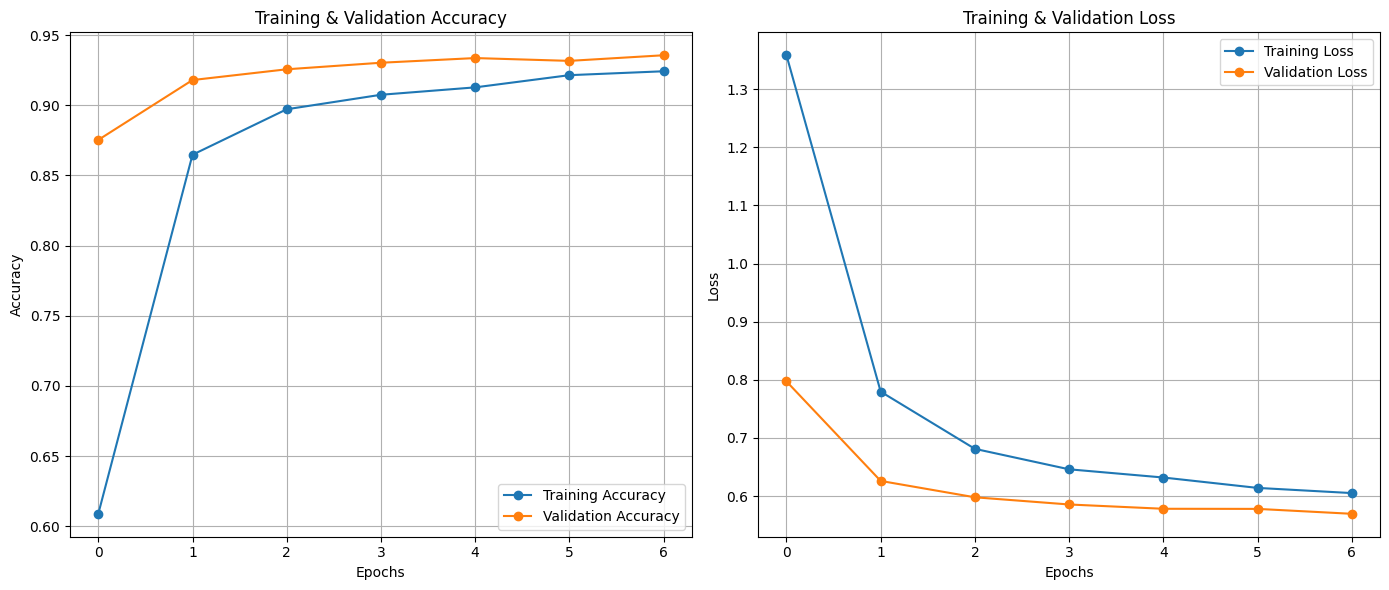

94/94 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step


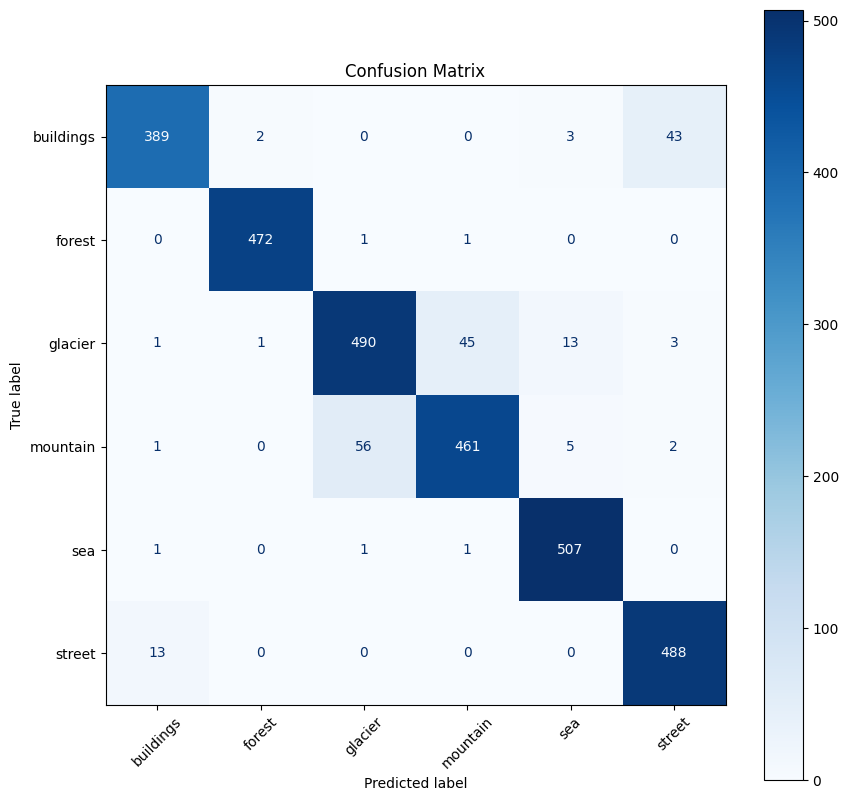


Classification Report:

              precision    recall  f1-score   support

   buildings       0.96      0.89      0.92       437
      forest       0.99      1.00      0.99       474
     glacier       0.89      0.89      0.89       553
    mountain       0.91      0.88      0.89       525
         sea       0.96      0.99      0.98       510
      street       0.91      0.97      0.94       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- 1. Accuracy & Loss Curves ---
plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_ft.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_ft.history['loss'], label='Training Loss', marker='o')
plt.plot(history_ft.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 2. Confusion Matrix ---
# Predict on test set
y_true = test_generator_ft.classes
y_pred = model.predict(test_generator_ft)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(test_generator_ft.class_indices.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

# --- 3. Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes,
                            target_names=list(test_generator_ft.class_indices.keys())))

# --- 4. Optional: Learning Rate Schedule ---
for cb in callbacks:
    if hasattr(cb, 'history') and 'lr' in cb.history:
        plt.figure(figsize=(6, 4))
        plt.plot(cb.history['lr'], marker='o')
        plt.title('Learning Rate Schedule')
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.grid(True)
        plt.show()
        break
